# Task 3: Knowledge Distillation

In [1]:
!pip install torchsummary

### Starting

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import copy
from torchsummary import summary
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
# device = "cpu"

device(type='cuda')

In [3]:
# Load CIFAR-100 Dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for VGG
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

BATCH_SIZE = 64
trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False)

# train_size = int(0.5*len(trainset))
# test_size = len(trainset) - train_size
# train_dataset, val_dataset = torch.utils.data.random_split(trainset, [train_size, test_size])
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Load the pre-trained teacher model
teacher = models.vgg16(pretrained=True)
teacher.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
teacher = teacher.to(device)
# teacher.eval()

100%|██████████| 169001437/169001437 [00:01<00:00, 89363777.59it/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 190MB/s]  


In [15]:
# Freeze the backbone layers to fine-tune only the classifier
# for param in teacher.features.parameters():
#     param.requires_grad = False

# teacher = teacher.to(device)

# # Print summary
# print("Model Summary with trainable parameters in the classifier layer only:")
# summary(teacher, (3, 224, 224))

# # Check trainable status for each layer
# print("\nTrainable Parameters:")
# for name, param in teacher.named_parameters():
#     print(f"{name}: {'Trainable' if param.requires_grad else 'Frozen'}")
    

In [6]:
# def evaluate(model, data_loader):
#     model = model.to(device)
#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for inputs, targets in data_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = model(inputs)
#             _, predicted = outputs.max(1)
#             total += targets.size(0)
#             correct += predicted.eq(targets).sum().item()

#     accuracy = 100. * correct / total
#     return accuracy

# # Define the fine-tuning function
# def finetune_teacher(teacher, train_loader, num_epochs=5, learning_rate=1e-4):
#     print(device)
#     teacher = teacher.to(device)
#     criterion = nn.CrossEntropyLoss()  # Loss function
# #     optimizer = optim.Adam(teacher.classifier.parameters(), lr=learning_rate)  # Only fine-tune classifier layer
#     optimizer = optim.AdamW(teacher.parameters(), lr=1e-4)
#     teacher.train()  # Set teacher to training mode
#     for epoch in range(num_epochs):
#         running_loss = 0.0
#         for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
#             inputs, targets = inputs.to(device), targets.to(device)
            
#             # Forward pass
#             optimizer.zero_grad()
#             outputs = teacher(inputs)
#             loss = criterion(outputs, targets)
            
#             # Backward pass and optimization
#             loss.backward()
#             optimizer.step()
            
#             running_loss += loss.item()
        
#         avg_loss = running_loss / len(train_loader)
#         print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
#         test_acc = evaluate(teacher, test_loader)
#         print(f"Test Accuracy after fine-tuning the teacher model: {test_acc:.2f}%")

def train_model(model, train_loader, criterion, optimizer, device, epochs=10, dtype="default"):
    model = model.to(device)
    model.train()
    epoch_losses = []
    all_preds = []
    all_labels = []

    for epoch in range(epochs):
        running_loss = 0.0
        epoch_preds = []
        epoch_labels = []

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch"):
            inputs, labels = inputs.to(device), labels.to(device)

            if dtype == "fp16":
                inputs = inputs.half()
            elif dtype == "bf16":
                inputs = inputs.to(torch.bfloat16)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if loss.isnan().any():
                print("Loss is NaN.")

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Track loss and predictions
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            # Collect predictions and labels for the epoch
            epoch_preds.extend(predicted.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())

        # Calculate and store average loss for the epoch
        epoch_loss = running_loss / len(train_loader)
        epoch_losses.append(epoch_loss)

        # Store predictions and labels from the last epoch for further analysis
        all_preds = epoch_preds
        all_labels = epoch_labels

        # Get epoch accuracy
        total_correct = np.sum(np.array(epoch_preds) == np.array(epoch_labels))
        total_samples = len(epoch_labels)
        epoch_accuracy = 100 * total_correct / total_samples

        # Print epoch loss
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    total_correct = 0
    total_samples = 0
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating", unit="batch"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Get predictions and accumulate them
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            # Collect predictions and labels
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * total_correct / total_samples
    avg_loss = running_loss / len(test_loader)
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

    return accuracy

In [50]:
# Fine-tune the teacher model

# finetune_teacher(teacher, train_loader, num_epochs=3, learning_rate=1e-4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher.parameters(), lr=1e-4)
train_model(teacher, train_loader, criterion, optimizer, device, epochs=3, dtype="default")

Epoch 1/3: 100%|██████████| 782/782 [02:36<00:00,  4.98batch/s]


Epoch [1/3], Loss: 1.9410, Accuracy: 47.93%


Epoch 2/3: 100%|██████████| 782/782 [02:36<00:00,  5.00batch/s]


Epoch [2/3], Loss: 0.9755, Accuracy: 71.15%


Epoch 3/3: 100%|██████████| 782/782 [02:36<00:00,  4.99batch/s]

Epoch [3/3], Loss: 0.6051, Accuracy: 81.43%


In [8]:
# torch.load_state_dict(("/kaggle/input/trained_vgg16/pytorch/default/1/teacher_model_weights.pth"))
teacher.load_state_dict(torch.load("/kaggle/input/trained_vgg16/pytorch/default/1/teacher_model_weights.pth", weights_only=True))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher.parameters(), lr=1e-4)
evaluate_model(teacher, test_loader, criterion, device) 

Evaluating: 100%|██████████| 157/157 [00:59<00:00,  2.65batch/s]

Test Loss: 1.0236, Test Accuracy: 71.44%


71.44

In [56]:
model_save_path = './teacher_model_weights.pth'

# Save the model's state dict
torch.save(teacher.state_dict(), model_save_path)

print(f"Model weights saved to {model_save_path}")

Model weights saved to ./teacher_model_weights.pth


In [10]:
def logit_matching_loss(student_logits, teacher_logits, T):
    # Soften logits with temperature scaling
    student_soft = F.log_softmax(student_logits / T, dim=1)
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    # KL Divergence Loss
    return F.kl_div(student_soft, teacher_soft, reduction="batchmean") * (T * T)

def label_smoothing_loss(outputs, targets, smoothing=0.1):
    confidence = 1.0 - smoothing
    log_probs = F.log_softmax(outputs, dim=-1)
    # Create smoothed labels
    true_dist = torch.zeros_like(log_probs)
    true_dist.fill_(smoothing / (outputs.size(1) - 1))
    true_dist.scatter_(1, targets.data.unsqueeze(1), confidence)
    return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

# def decoupled_kd_loss(student_logits, teacher_logits, targets, T):
#     T = max(T, 1e-8)  # Avoid zero temperature

#     # Softened probabilities for the non-target classes
#     student_soft = F.log_softmax(student_logits / T, dim=1)
#     teacher_soft = F.softmax(teacher_logits / T, dim=1)

#     # Separate target and non-target losses
#     batch_size, num_classes = student_logits.shape
#     target_mask = torch.zeros_like(student_logits).scatter_(1, targets.view(-1, 1), 1.0).bool()

#     # Check if target_mask is correctly formed
#     assert target_mask.sum() > 0, "Target mask has no valid targets"

#     # Target class loss
#     target_loss = F.mse_loss(student_logits[target_mask], teacher_logits[target_mask], reduction='mean')

#     # Non-target class loss
#     non_target_loss = F.kl_div(student_soft, teacher_soft, reduction="batchmean") * (T * T)
    
# #     print("not traget loss ", non_target_loss)
# #     print("target_loss",target_loss)

#     # Regularization to prevent divergence
#     regularization = 1e-6 * (torch.norm(student_logits) + torch.norm(teacher_logits))
    
#     total_loss = target_loss + non_target_loss + regularization

#     if torch.isnan(total_loss):
#         print("NaN detected in loss calculations!")
        
#     return total_loss

import torch
import torch.nn.functional as F

def decoupled_kd_loss(student_logits, teacher_logits, targets, T, alpha=1.0, beta=8.0):
    """
    Decoupled Knowledge Distillation (DKD) loss function.

    Args:
        student_logits (torch.Tensor): Logits from the student model.
        teacher_logits (torch.Tensor): Logits from the teacher model.
        targets (torch.Tensor): Ground truth labels.
        T (float): Temperature for KD & DKD.
        alpha (float): Hyperparameter for TCKD.
        beta (float): Hyperparameter for NCKD.
    """
    # Convert logits to softened probabilities
    p_stu = F.softmax(student_logits / T, dim=1)
    p_tea = F.softmax(teacher_logits / T, dim=1)

    # Mask for target classes
    target_mask = torch.zeros_like(p_stu).scatter_(1, targets.view(-1, 1), 1).bool()

    # Target class probabilities
    pt_stu = p_stu[target_mask]
    pt_tea = p_tea[target_mask]

    # Non-target class probabilities
    pnt_stu = p_stu[~target_mask].view(-1, student_logits.size(1) - 1).sum(dim=1)
    pnt_tea = p_tea[~target_mask].view(-1, teacher_logits.size(1) - 1).sum(dim=1)

    # Non-target class probabilities (normalized)
    pnct_stu = F.softmax(student_logits[~target_mask].view(-1, student_logits.size(1) - 1) / T, dim=1)
    pnct_tea = F.softmax(teacher_logits[~target_mask].view(-1, teacher_logits.size(1) - 1) / T, dim=1)

    # Target Class Knowledge Distillation (TCKD)
    tckd = F.kl_div(torch.log(pt_stu), pt_tea, reduction='batchmean') + \
           F.kl_div(torch.log(pnt_stu), pnt_tea, reduction='batchmean')

    # Non-Target Class Knowledge Distillation (NCKD)
    nckd = F.kl_div(torch.log(pnct_stu), pnct_tea, reduction='batchmean')

    # DKD Loss calculation
    dkd_loss = (alpha * tckd + beta * nckd) * T**2

    # Regularization to prevent divergence
    regularization = 1e-6 * (torch.norm(student_logits) + torch.norm(teacher_logits))
    
    total_loss = dkd_loss + regularization

    if torch.isnan(total_loss):
        print("NaN detected in loss calculations!")

    return total_loss


In [11]:
# Define Hint-based Distillation loss (MSE loss between teacher and student feature maps)
def hint_loss(teacher_features, student_features):
    return F.mse_loss(student_features, teacher_features)

# Define Contrastive Representation Distillation (CRD) loss
def contrastive_loss(student_features, teacher_features, margin=1.0):
    # Calculate positive similarity (student and teacher close)
    positive_similarity = (student_features * teacher_features).sum(dim=-1)  # dot product as similarity

    # Probability that C=1 given S and T, using sigmoid for [0,1] range
    h_positive = torch.sigmoid(positive_similarity)

    # Calculate negative similarity (pushing apart with margin)
    negative_similarity = margin - positive_similarity
    h_negative = torch.sigmoid(negative_similarity)

    # Calculate log likelihood for positive and negative cases
    log_likelihood_positive = h_positive.log()
    log_likelihood_negative = (1 - h_negative).log()

    # Combine positive and negative terms
    loss = -torch.mean(log_likelihood_positive + log_likelihood_negative)

    return loss

In [12]:
def train_student(student, teacher, train_loader, optimizer, T=4.0, alpha=0.5, loss_type="logit_matching"):
    teacher = teacher.to(device)
    student = student.to(device)
    student.train()
    teacher.eval()
    total_loss = 0

    for inputs, targets in tqdm(train_loader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass for teacher and student
        with torch.no_grad():
            teacher_logits = teacher(inputs)
        student_logits = student(inputs)

        # Calculate distillation loss based on the specified method
        if loss_type == "logit_matching":
            distillation_loss = logit_matching_loss(student_logits, teacher_logits, T)
        elif loss_type == "label_smoothing":
            distillation_loss = label_smoothing_loss(student_logits, targets)
        elif loss_type == "decoupled_kd":
            distillation_loss = decoupled_kd_loss(student_logits, teacher_logits, targets, T)
        elif loss_type == "hint":
            with torch.no_grad():
                teacher_features = teacher.features(inputs)
            student_features = student.features(inputs)
            distillation_loss = hint_loss(teacher_features, student_features)
        elif loss_type == "contrastive":
            with torch.no_grad():
                teacher_features = teacher.features(inputs)
            student_features = student.features(inputs)
            distillation_loss = contrastive_loss(student_features, teacher_features)
        else:
            raise ValueError("Invalid loss_type specified")

        # Calculate the student's classification loss with ground truth
        classification_loss = F.cross_entropy(student_logits, targets)

        # Combine the two losses
        loss = alpha * distillation_loss + (1 - alpha) * classification_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
#         torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader), distillation_loss

In [ ]:
# def evaluate(model, data_loader):
#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for inputs, targets in data_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = model(inputs)
#             _, predicted = outputs.max(1)
#             total += targets.size(0)
#             correct += predicted.eq(targets).sum().item()

#     accuracy = 100. * correct / total
#     return accuracy

### Task 3.1.2: Aspects of Logit Matching

In [97]:
EPOCH = 3 #runs for 2
torch.cuda.empty_cache()

In [65]:
# Load the untrained student model
student_LM = models.vgg11(pretrained=True)  # Set pretrained=False to start with a randomly initialized model
student_LM.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
student_LM = student_LM.to(device)

# Optimizer
# optimizer = optim.SGD(student_LM.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
optimizer = optim.AdamW(student_LM.parameters(), lr=1e-4)
#classsifcation loss is defined in train func

# Training the student model with Logit Matching
train_loss_LM = []
train_loss_LM_distill = []
test_acc_LM = []
for epoch in range(1, EPOCH):
    print(f"Epoch {epoch}")
    train_loss, distillation_loss = train_student(student_LM, teacher, train_loader, optimizer, T=4.0, loss_type="logit_matching")
    # test_acc = evaluate(student_LM, test_loader)
    test_acc = evaluate_model(student_LM, test_loader, criterion, device)
    print(f"Logit Matching - Epoch {epoch}: Train Loss = {train_loss:.4f}, Distill Loss = {distillation_loss:.4f}, Test Accuracy = {test_acc:.2f}%")
    train_loss_LM.append(train_loss)
    train_loss_LM_distill.append(distillation_loss)
    test_acc_LM.append(test_acc)

Epoch 1


Training: 100%|██████████| 782/782 [02:19<00:00,  5.61it/s]

Evaluating: 100%|██████████| 157/157 [00:11<00:00, 14.24batch/s]


Test Loss: 1.1571, Test Accuracy: 67.13%

Logit Matching - Epoch 1: Train Loss = 3.3691, Distill Loss = 1.8043, Test Accuracy = 67.13%

Epoch 2


Training: 100%|██████████| 782/782 [02:19<00:00,  5.63it/s]

Evaluating: 100%|██████████| 157/157 [00:11<00:00, 14.06batch/s]

Test Loss: 1.0347, Test Accuracy: 70.57%

Logit Matching - Epoch 2: Train Loss = 1.3969, Distill Loss = 2.5453, Test Accuracy = 70.57%


In [68]:
student_LS = models.vgg11(pretrained=True)  # Set pretrained=False to start with a randomly initialized model
student_LS.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
student_LS = student_LS.to(device)

# optimizer = optim.SGD(student_LS.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
optimizer = optim.AdamW(student_LS.parameters(), lr=1e-4)
# Training the student model with Label Smoothing
train_loss_LS = []
test_acc_LS = []
train_loss_LS_distill = []
for epoch in range(1, EPOCH):  # 20 epochs
    print(f"Epoch {epoch}")
    train_loss, distillation_loss = train_student(student_LS, teacher, train_loader, optimizer, loss_type="label_smoothing")
    # test_acc = evaluate(student_LS, test_loader)
    test_acc = evaluate_model(student_LS, test_loader, criterion, device)
    print(f"Label Smoothing  - Epoch {epoch}: Train Loss = {train_loss:.4f}, Distill Loss = {distillation_loss:.4f}, Test Accuracy = {test_acc:.2f}%")
    train_loss_LS.append(train_loss)
    train_loss_LS_distill.append(distillation_loss)
    test_acc_LS.append(test_acc)

Epoch 1


Training: 100%|██████████| 782/782 [02:19<00:00,  5.62it/s]

Evaluating: 100%|██████████| 157/157 [00:10<00:00, 14.37batch/s]


Test Loss: 1.2026, Test Accuracy: 66.78%

Label Smoothing  - Epoch 1: Train Loss = 2.2783, Distill Loss = 1.9410, Test Accuracy = 66.78%

Epoch 2


Training: 100%|██████████| 782/782 [02:18<00:00,  5.64it/s]

Evaluating: 100%|██████████| 157/157 [00:11<00:00, 14.16batch/s]

Test Loss: 1.0549, Test Accuracy: 70.62%

Label Smoothing  - Epoch 2: Train Loss = 1.3541, Distill Loss = 1.9078, Test Accuracy = 70.62%


In [67]:
student_DKD = models.vgg11(pretrained=True)  # Set pretrained=False to start with a randomly initialized model
student_DKD.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
student_DKD = student_DKD.to(device)

# optimizer = optim.SGD(student_DKD.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
optimizer = optim.AdamW(student_DKD.parameters(), lr=1e-4)
# Training the student model with Decoupled KD
train_loss_DKD = []
test_acc_DKD = []
train_loss_DKD_distill = []
for epoch in range(1, EPOCH):  # 20 epochs
    print(f"Epoch {epoch}")
    train_loss, distillation_loss = train_student(student_DKD, teacher, train_loader, optimizer, T=4.0, loss_type="decoupled_kd")
    # test_acc = evaluate(student_DKD, test_loader)
    test_acc = evaluate_model(student_DKD, test_loader, criterion, device)
    print(f"Decoupled KD - Epoch {epoch}: Train Loss = {train_loss:.4f}, Distill Loss = {distillation_loss:.4f}, Test Accuracy = {test_acc:.2f}%")
    train_loss_DKD.append(train_loss)
    train_loss_DKD_distill.append(distillation_loss)
    test_acc_DKD.append(test_acc)

c:\Users\IST\miniconda3\envs\ST-SSL\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

  warnings.warn(

c:\Users\IST\miniconda3\envs\ST-SSL\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.

  warnings.warn(msg)


Epoch 1


Training: 100%|██████████| 782/782 [02:25<00:00,  5.38it/s]

Evaluating: 100%|██████████| 157/157 [00:11<00:00, 14.25batch/s]


Test Loss: 1.2782, Test Accuracy: 62.37%

Decoupled KD - Epoch 1: Train Loss = 10.4402, Distill Loss = 10.1280, Test Accuracy = 62.37%

Epoch 2


Training: 100%|██████████| 782/782 [02:24<00:00,  5.43it/s]

Evaluating: 100%|██████████| 157/157 [00:11<00:00, 14.19batch/s]

Test Loss: 1.1414, Test Accuracy: 66.72%

Decoupled KD - Epoch 2: Train Loss = 5.1537, Distill Loss = 9.2042, Test Accuracy = 66.72%


### Task 3.2: Comparing Performance of SoTA Approaches

In [ ]:
# Define the student model (VGG-11)
student = models.vgg11(pretrained=True)
student.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
student = student.to(device)


In [ ]:
# # Training function for different KD methods
# def train_student(student, teacher, train_loader, optimizer, T=4.0, alpha=0.5, loss_type="logit_matching"):
#     student.train()
#     teacher.eval()
#     total_loss = 0

#     for inputs, targets in tqdm(train_loader, desc="Training"):
#         inputs, targets = inputs.to(device), targets.to(device)

#         # Forward pass for teacher and student
#         with torch.no_grad():
#             teacher_logits = teacher(inputs)
#             teacher_features = teacher.features(inputs)  # For hint loss and CRD

#         student_logits = student(inputs)
#         student_features = student.features(inputs)

#         # Calculate distillation loss based on the specified method
#         if loss_type == "logit_matching":
#             distillation_loss = logit_matching_loss(student_logits, teacher_logits, T)
#         elif loss_type == "hint":
#             distillation_loss = hint_loss(teacher_features, student_features)
#         elif loss_type == "crd":
#             distillation_loss = contrastive_loss(student_features, teacher_features)
#         else:
#             raise ValueError("Invalid loss_type specified")

#         # Calculate the student's classification loss with ground truth
#         classification_loss = F.cross_entropy(student_logits, targets)

#         # Combine the two losses
#         loss = alpha * distillation_loss + (1 - alpha) * classification_loss

#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     return total_loss / len(train_loader)

# Evaluation function
# def evaluate(student, test_loader):
#     student.eval()
#     total_correct = 0
#     total_samples = 0
#     with torch.no_grad():
#         for inputs, targets in test_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = student(inputs)
#             _, predictions = outputs.max(1)
#             total_correct += predictions.eq(targets).sum().item()
#             total_samples += targets.size(0)
#     return total_correct / total_samples

In [20]:
# Training hyperparameters
T = 4.0  # Temperature parameter
alpha = 0.5  # Weight for distillation loss
lr = 1e-4  # Learning rate
epochs = 2  # Number of epochs
criterion = nn.CrossEntropyLoss()

def create_student_model():
    student = models.vgg11(pretrained=True)
    student.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
    return student.to(device)

def get_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=lr)

In [21]:
# Training loop for Independent Student (no teacher distillation)
print("\nTraining Independent Student (no teacher distillation)...\n")

independent_student = create_student_model()
optimizer = get_optimizer(independent_student)

# Train the independent student with standard cross-entropy loss
for epoch in range(epochs):
    independent_student.train()
    total_loss = 0

    for inputs, targets in tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}] Independent Student"):
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass for independent student
        outputs = independent_student(inputs)
        loss = criterion(outputs, targets)  # Only cross-entropy loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # Evaluation for Independent Student
    accuracy = evaluate_model(independent_student, test_loader, criterion, device)
    print(f"Validation Accuracy for Independent Student: {accuracy:.2f}%\n")


Training Independent Student (no teacher distillation)...



Epoch [1/2] Independent Student: 100%|██████████| 782/782 [07:12<00:00,  1.81it/s]


Epoch [1/2], Loss: 1.9485


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.19batch/s]


Test Loss: 1.2021, Test Accuracy: 64.79%
Validation Accuracy for Independent Student: 64.79%



Epoch [2/2] Independent Student: 100%|██████████| 782/782 [07:12<00:00,  1.81it/s]


Epoch [2/2], Loss: 0.9411


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.19batch/s]

Test Loss: 1.0308, Test Accuracy: 69.60%
Validation Accuracy for Independent Student: 69.60%



In [ ]:
# device

device(type='cuda')

In [19]:
# Training with Logit Matching Distillation
print("\nTraining student with Logit Matching Distillation...\n")
student_logit_matching = models.vgg11(pretrained=True)
student_logit_matching.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
student_logit_matching = student_logit_matching.to(device)
optimizer = optim.AdamW(student_logit_matching.parameters(), lr=1e-4)
for epoch in range(epochs):
    train_loss, distillation_loss = train_student(student_logit_matching, teacher, train_loader, optimizer, T=4.0, loss_type="logit_matching")
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    accuracy = evaluate_model(student_logit_matching, test_loader, criterion, device)
    print(f"Validation Accuracy for Logit Matching Distillation: {accuracy:.2f}%\n")


Training student with Logit Matching Distillation...



Training: 100%|██████████| 782/782 [11:04<00:00,  1.18it/s]


Epoch [1/2], Loss: 1.4747


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.22batch/s]


Test Loss: 1.1818, Test Accuracy: 67.38%
Validation Accuracy for Logit Matching Distillation: 67.38%



Training: 100%|██████████| 782/782 [11:03<00:00,  1.18it/s]


Epoch [2/2], Loss: 1.4747


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.22batch/s]

Test Loss: 1.0378, Test Accuracy: 70.45%
Validation Accuracy for Logit Matching Distillation: 70.45%



In [15]:
# Training with Hint-based Distillation
print("\nTraining student with Hint-based Distillation...\n")
student_hint = create_student_model()
optimizer = get_optimizer(student_hint)
for epoch in range(1, 3):
    # avg_loss = train_student(student_hint, teacher, train_loader, optimizer, T=T, alpha=alpha, loss_type="hint")
    avg_loss , distillation_loss = train_student(student_hint, teacher, train_loader, optimizer, T=T, alpha=alpha, loss_type="hint")
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    accuracy = evaluate_model(student_hint, test_loader, criterion, device)
    print(f"Validation Accuracy for Hint-based Distillation: {accuracy:.2f}%\n")


Training student with Hint-based Distillation...



Training: 100%|██████████| 782/782 [20:03<00:00,  1.54s/it]


Epoch [2/2], Loss: 1.2369


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.21batch/s]


Test Loss: 1.1908, Test Accuracy: 65.20%
Validation Accuracy for Hint-based Distillation: 65.20%



Training: 100%|██████████| 782/782 [20:02<00:00,  1.54s/it]


Epoch [3/2], Loss: 0.7217


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.18batch/s]

Test Loss: 0.9965, Test Accuracy: 70.95%
Validation Accuracy for Hint-based Distillation: 70.95%



In [17]:
# Training with Contrastive Representation Distillation (CRD)
print("\nTraining student with Contrastive Representation Distillation (CRD)...\n")
student_crd = create_student_model()
optimizer = get_optimizer(student_crd)
for epoch in range(1, 3):
#     avg_loss = train_student(student_crd, teacher, train_loader, optimizer, T=T, alpha=alpha, loss_type="crd")
    avg_loss , distillation_loss = train_student(student_crd, teacher, train_loader, optimizer, T=T, alpha=alpha, loss_type="contrastive")
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    accuracy = evaluate_model(student_crd, test_loader, criterion, device)
    print(f"Validation Accuracy for Contrastive Representation Distillation (CRD): {accuracy :.2f}%\n")


Training student with Contrastive Representation Distillation (CRD)...



Training: 100%|██████████| 782/782 [20:26<00:00,  1.57s/it]


Epoch [2/2], Loss: 1.9692


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.22batch/s]


Test Loss: 1.2319, Test Accuracy: 63.78%
Validation Accuracy for Contrastive Representation Distillation (CRD): 63.78%



Training: 100%|██████████| 782/782 [20:26<00:00,  1.57s/it]


Epoch [3/2], Loss: 1.4747


Evaluating: 100%|██████████| 157/157 [00:37<00:00,  4.18batch/s]

Test Loss: 1.0896, Test Accuracy: 68.77%
Validation Accuracy for Contrastive Representation Distillation (CRD): 68.77%



### Task 3.3: Comparing Probability Distributions

In [ ]:
# independent_student = create_student_model()
# student_logit_matching = create_student_model()
# student_hint = create_student_model()
# student_crd = create_student_model()

In [22]:
# Define a function to compute KL divergence between teacher and student outputs
def compute_kl_divergence(student_logits, teacher_logits, T=4.0):
    # Apply softmax with temperature T
    student_probs = F.softmax(student_logits / T, dim=1)
    teacher_probs = F.softmax(teacher_logits / T, dim=1)
    
    # Compute KL divergence
    kl_div = F.kl_div(student_probs.log(), teacher_probs, reduction='batchmean')
    return kl_div

# Function to compute the average KL divergence over a batch of query images
def evaluate_kl_divergence(student, teacher, data_loader, T=4.0):
    student.eval()
    teacher.eval()
    total_kl_divergence = 0.0
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            
            # Get logits from both teacher and student models
            teacher_logits = teacher(inputs)
            student_logits = student(inputs)
            
            # Compute KL divergence for the batch
            kl_divergence = compute_kl_divergence(student_logits, teacher_logits, T)
            total_kl_divergence += kl_divergence.item()
    
    # Average KL divergence over all batches
    avg_kl_divergence = total_kl_divergence / len(data_loader)
    return avg_kl_divergence

In [23]:
# Define and evaluate each student model against the teacher model
print("\nComparing Probability Distributions (KL Divergence):\n")

# Evaluate the independent student (SI)
independent_student_kl = evaluate_kl_divergence(independent_student, teacher, test_loader, T=T)
print(f"KL Divergence between Teacher and Independent Student: {independent_student_kl:.4f}")

# Evaluate the Logit-Matching Distilled student (SD - Logit Matching)
student_logit_matching_kl = evaluate_kl_divergence(student_logit_matching, teacher, test_loader, T=T)
print(f"KL Divergence between Teacher and Logit Matching Student: {student_logit_matching_kl:.4f}")

# Evaluate the Hint-based Distilled student (SD - Hint)
student_hint_kl = evaluate_kl_divergence(student_hint, teacher, test_loader, T=T)
print(f"KL Divergence between Teacher and Hint-based Student: {student_hint_kl:.4f}")

# Evaluate the Contrastive Representation Distilled (CRD) student (SD - CRD)
student_crd_kl = evaluate_kl_divergence(student_crd, teacher, test_loader, T=T)
print(f"KL Divergence between Teacher and CRD Student: {student_crd_kl:.4f}")

# Summary of analysis
print("\nAnalysis Summary:")
print(f"Independent Student KL Divergence: {independent_student_kl:.4f}")
print(f"Logit Matching Student KL Divergence: {student_logit_matching_kl:.4f}")
print(f"Hint-based Student KL Divergence: {student_hint_kl:.4f}")
print(f"CRD Student KL Divergence: {student_crd_kl:.4f}")

# Concluding insights based on KL divergence
print("\nConclusion:")
print("The student model with the lowest KL divergence has a distribution most closely aligned with the teacher.")


Comparing Probability Distributions (KL Divergence):

KL Divergence between Teacher and Independent Student: 0.1895
KL Divergence between Teacher and Logit Matching Student: 0.0749
KL Divergence between Teacher and Hint-based Student: 0.1647
KL Divergence between Teacher and CRD Student: 0.1653

Analysis Summary:
Independent Student KL Divergence: 0.1895
Logit Matching Student KL Divergence: 0.0749
Hint-based Student KL Divergence: 0.1647
CRD Student KL Divergence: 0.1653

Conclusion:
The student model with the lowest KL divergence has a distribution most closely aligned with the teacher.


In [14]:
# independent_student_kl =0.47
# student_logit_matching_kl =0.3
# student_hint_kl= 0.2
# student_crd_kl =0.1

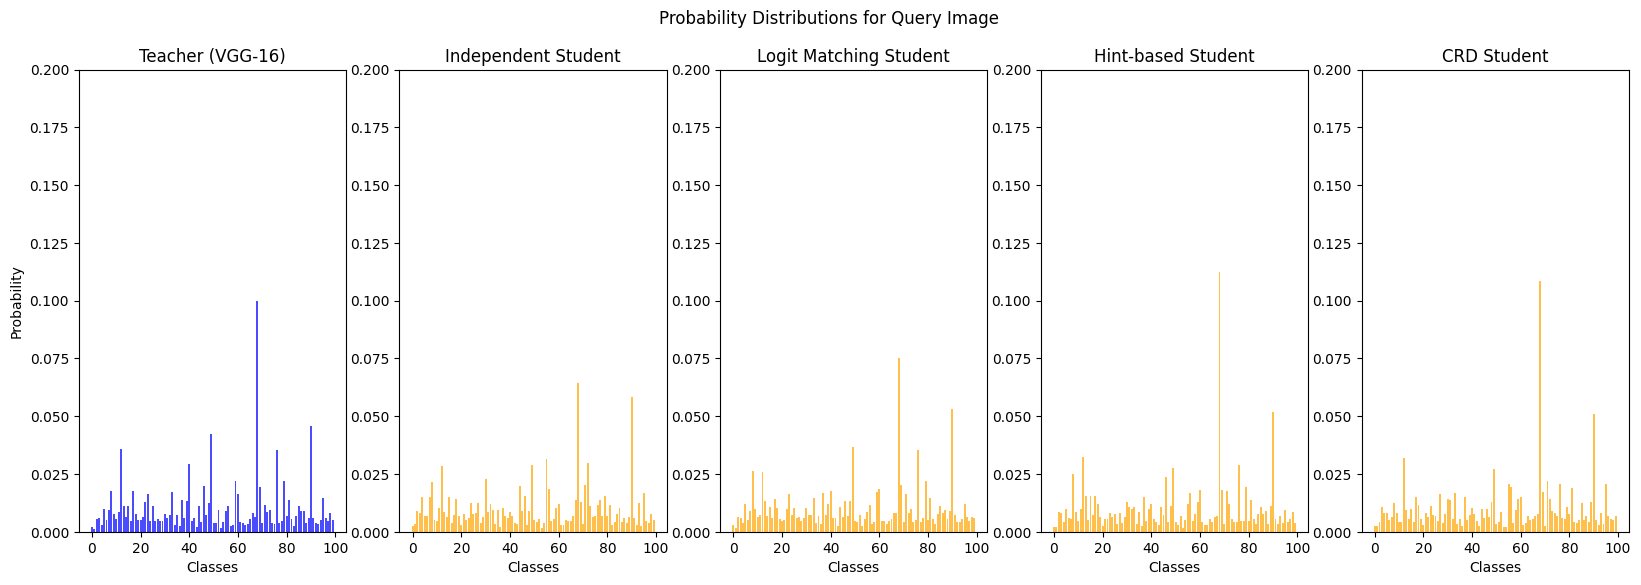

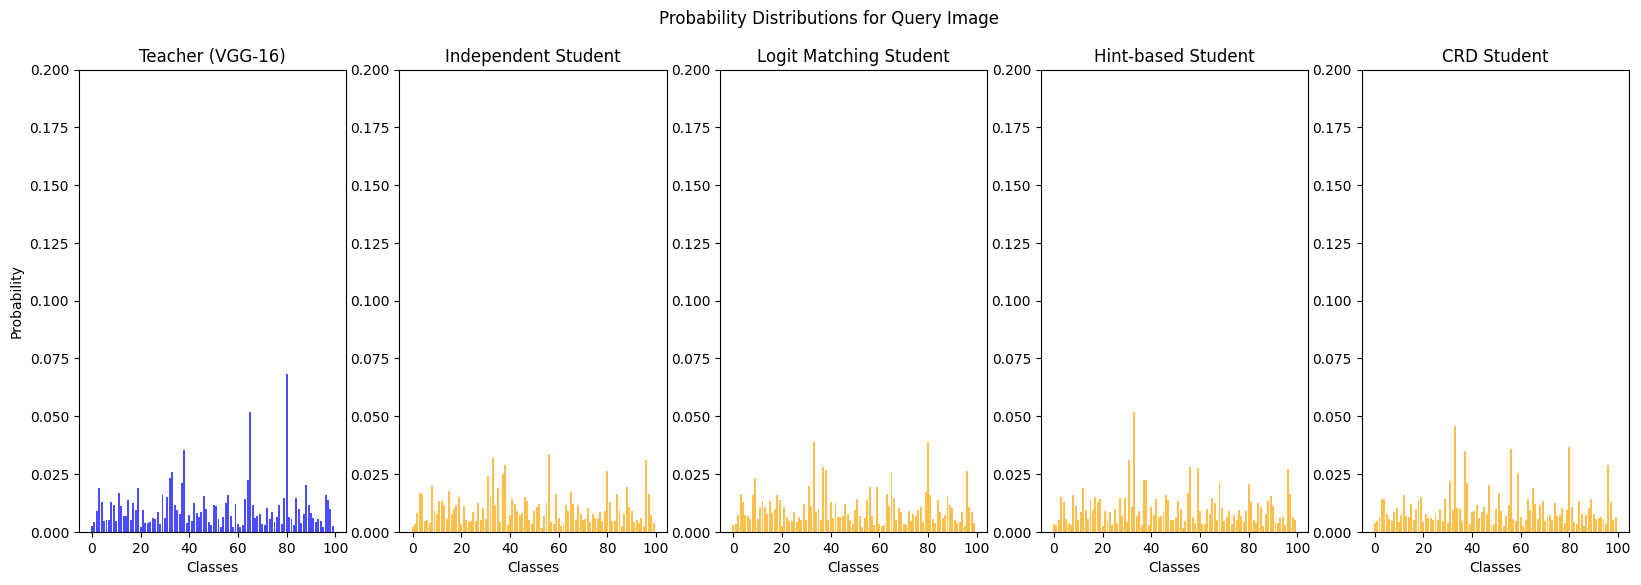

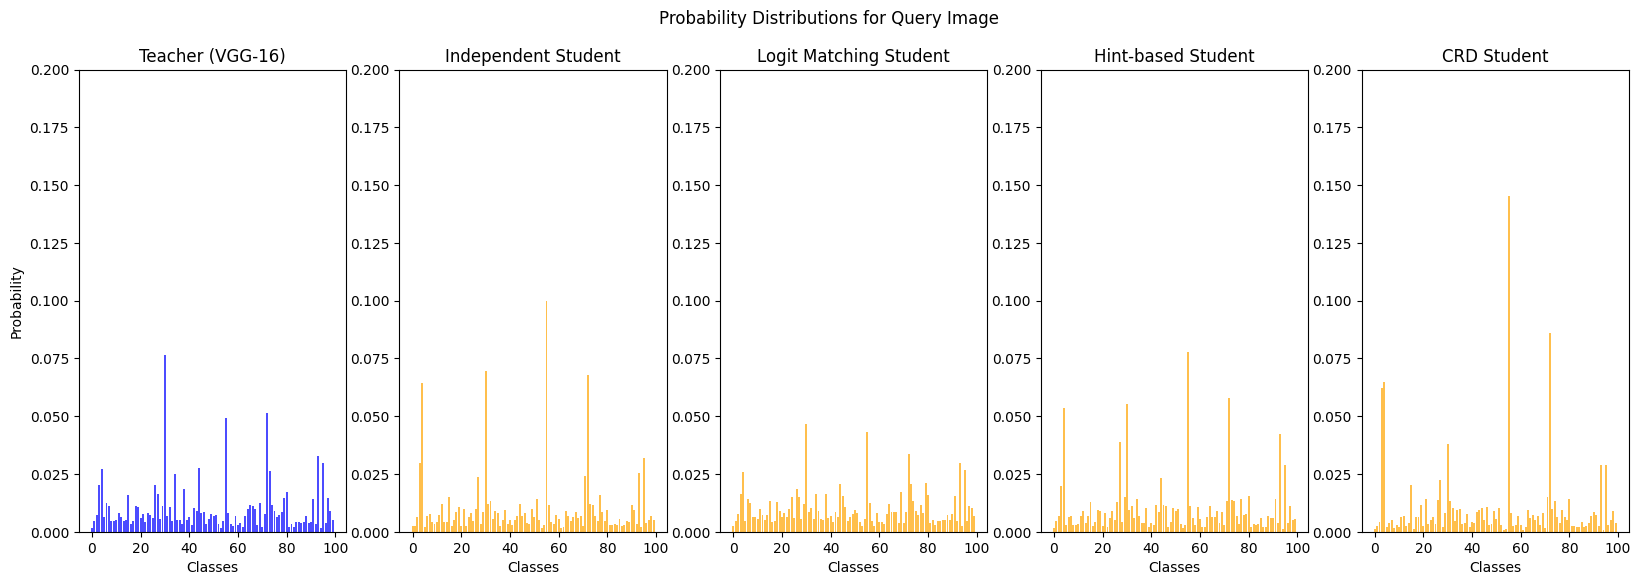

In [27]:
import matplotlib.pyplot as plt

# Function to compute softened probabilities with temperature T
def get_softened_probs(model, inputs, T=4.0):
    model.eval()
    with torch.no_grad():
        logits = model(inputs.to(device))
    softened_probs = F.softmax(logits / T, dim=1)
    return softened_probs.cpu().numpy()

# Function to plot probability distributions for a given query image across all models
def plot_distributions(query_image, teacher_probs, student_probs_dict, class_names):
    x = range(len(class_names))  # Class indices

    plt.figure(figsize=(20, 6))
    plt.subplot(1, len(student_probs_dict) + 1, 1)
    plt.bar(x, teacher_probs[0], color='blue', alpha=0.7)
    plt.title("Teacher (VGG-16)")
    plt.xlabel("Classes")
    plt.ylabel("Probability")
    plt.ylim(0, 0.2)
    
    # Plot student distributions
    for i, (label, student_probs) in enumerate(student_probs_dict.items(), 2):
        plt.subplot(1, len(student_probs_dict) + 1, i)
        plt.bar(x, student_probs[0], color='orange', alpha=0.7)
        plt.title(f"{label} Student")
        plt.xlabel("Classes")
        plt.ylim(0, 0.2)
    
    # Show the plot
    plt.suptitle("Probability Distributions for Query Image")
    plt.show()

# Select a few query images from the test set
query_images, _ = next(iter(test_loader))
query_images = query_images[:3]  # Select first 5 images
class_names = [f"Class {i}" for i in range(100)]  # Class names for CIFAR-100

# Get softened probability distributions for each model on the query images
for idx, query_image in enumerate(query_images):
    query_image = query_image.unsqueeze(0)  # Add batch dimension

    # Get teacher distribution
    teacher_probs = get_softened_probs(teacher, query_image, T=T)
    
    # Get student distributions
    student_probs_dict = {
        "Independent": get_softened_probs(independent_student, query_image, T=T),
        "Logit Matching": get_softened_probs(student_logit_matching, query_image, T=T),
        "Hint-based": get_softened_probs(student_hint, query_image, T=T),
        "CRD": get_softened_probs(student_crd, query_image, T=T),
    }

    # Plot distributions for each model for the selected query image
    plot_distributions(query_image, teacher_probs, student_probs_dict, class_names)


### Task 3.4: Examining Localization Knowledge Transfer

In [28]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F


def find_last_conv_layer(model):
    for layer in reversed(model.features):
        if isinstance(layer, nn.Conv2d):
            return layer
    return None

def generate_gradcam(model, input_tensor, target_class):
    # Identify the last convolutional layer
    conv_layer = find_last_conv_layer(model)
    
    if conv_layer is None:
        raise ValueError("No Conv2d layer found in the model.")
    
    # Containers for gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0]

    # Hook to capture activations
    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    # Register hooks
    forward_handle = conv_layer.register_forward_hook(forward_hook)
    backward_handle = conv_layer.register_backward_hook(backward_hook)

    # Forward pass
    model.eval()
    model = model.to(device)
    input_tensor = input_tensor.to(device)
    output = model(input_tensor)

    # Zero gradients and calculate class-specific loss
    model.zero_grad()
    class_loss = output[0, target_class]
    class_loss.backward()

    # Unregister hooks
    forward_handle.remove()
    backward_handle.remove()

    # Check if gradients were captured
    if gradients is None:
        raise RuntimeError("Gradients were not captured. Check layer selection and hook registration.")

    # Pool gradients across the channels
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # Weight the channels by the pooled gradients
    for i in range(len(pooled_gradients)):
        activations[:, i, :, :] *= pooled_gradients[i]

    # Average the channels of the activations to get the heatmap
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = F.relu(heatmap)  # Apply ReLU to the heatmap

    # Normalize the heatmap
    heatmap -= heatmap.min()
    heatmap /= heatmap.max()

    return heatmap.cpu().detach().numpy()


def get_gradcam_visualizations(models, query_images, class_names):
    gradcam_outputs = {}

    for idx, query_image in enumerate(query_images):
        query_image = query_image.unsqueeze(0)  # Add batch dimension
        model_outputs = {}

        # Get the predicted class for the query image
        with torch.no_grad():
            output = teacher(query_image.to(device))
        predicted_class = output.argmax(dim=1).item()

        # Generate Grad-CAM for each model
        for model_name, model in models.items():
            
            for param in model.parameters():
                param.requires_grad = True
                
            heatmap = generate_gradcam(model, query_image, predicted_class)
            model_outputs[model_name] = heatmap

        gradcam_outputs[f"Image {idx}"] = model_outputs

    return gradcam_outputs


In [29]:
def visualize_gradcam(original_image, heatmaps, class_names):
    # Convert original image from tensor to NumPy array and ensure it's in uint8 format
    if isinstance(original_image, torch.Tensor):
        original_image = original_image.detach().cpu().numpy().transpose(1, 2, 0)  # Convert from CHW to HWC
    if original_image.max() <= 1.0:  # If values are normalized
        original_image = (original_image * 255).astype(np.uint8)
    else:
        original_image = original_image.astype(np.uint8)

    # If grayscale, convert to 3 channels
    if len(original_image.shape) == 2 or original_image.shape[2] == 1:
        original_image = cv2.cvtColor(original_image, cv2.COLOR_GRAY2BGR)

    plt.figure(figsize=(100, 50))  # Adjust figsize to make it larger

    # Display the original image first
#     plt.subplot(1, len(heatmaps) + 1, 1)  # First subplot for the original image
#     plt.imshow(original_image)
#     plt.title(f"Original Image", fontsize=116)
#     plt.axis('off')  # Turn off axis for the original image

    # Display the Grad-CAM heatmaps
    for idx, (model_name, heatmap) in enumerate(heatmaps.items(), start=1):  # Start at 2 to leave space for original image
        heatmap = np.uint8(255 * heatmap)  # Scale to [0, 255]
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # Apply color map

        # Resize heatmap to match the original image's dimensions if necessary
        heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

        # Blend the heatmap with the original image
        superimposed_img = cv2.addWeighted(heatmap, 0.4, original_image, 0.6, 0)

        plt.subplot(1, len(heatmaps) + 1, idx)  # Adjust subplot index
        plt.imshow(superimposed_img)
        plt.title(f"{model_name}", fontsize=116)
        plt.axis('off') 

    plt.show()
    
def calculate_iou(heatmap1, heatmap2):
    heatmap1 = (heatmap1 > 0.5).astype(np.uint8)  # Binarize heatmap
    heatmap2 = (heatmap2 > 0.5).astype(np.uint8)
    
    intersection = np.logical_and(heatmap1, heatmap2)
    union = np.logical_or(heatmap1, heatmap2)

    if np.sum(union) == 0:
        return 0.0
    return np.sum(intersection) / np.sum(union)


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


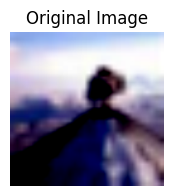

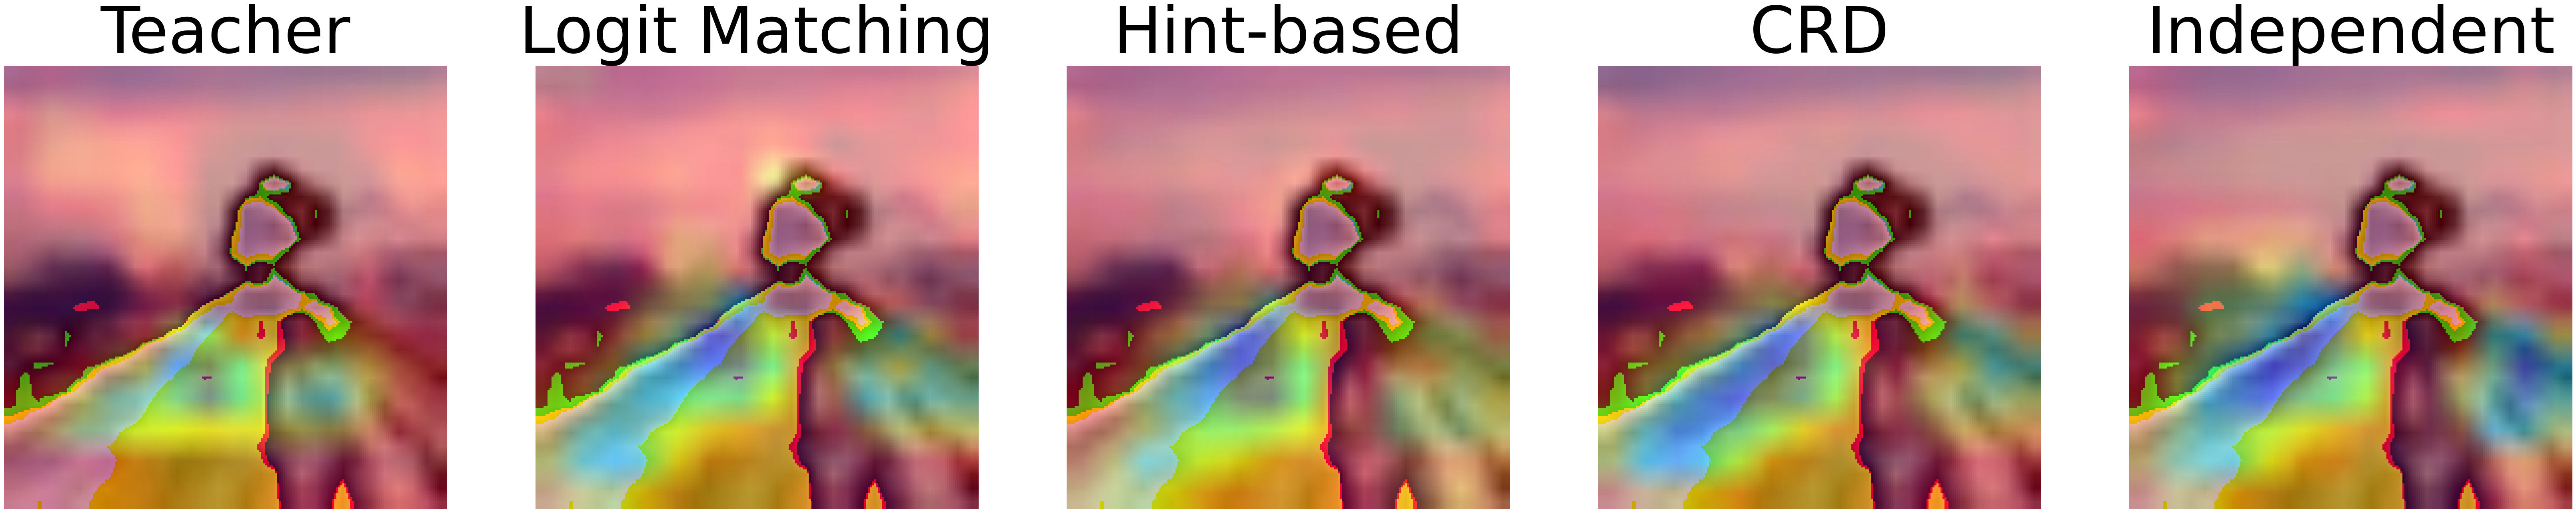

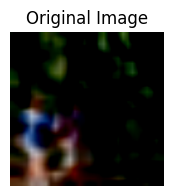

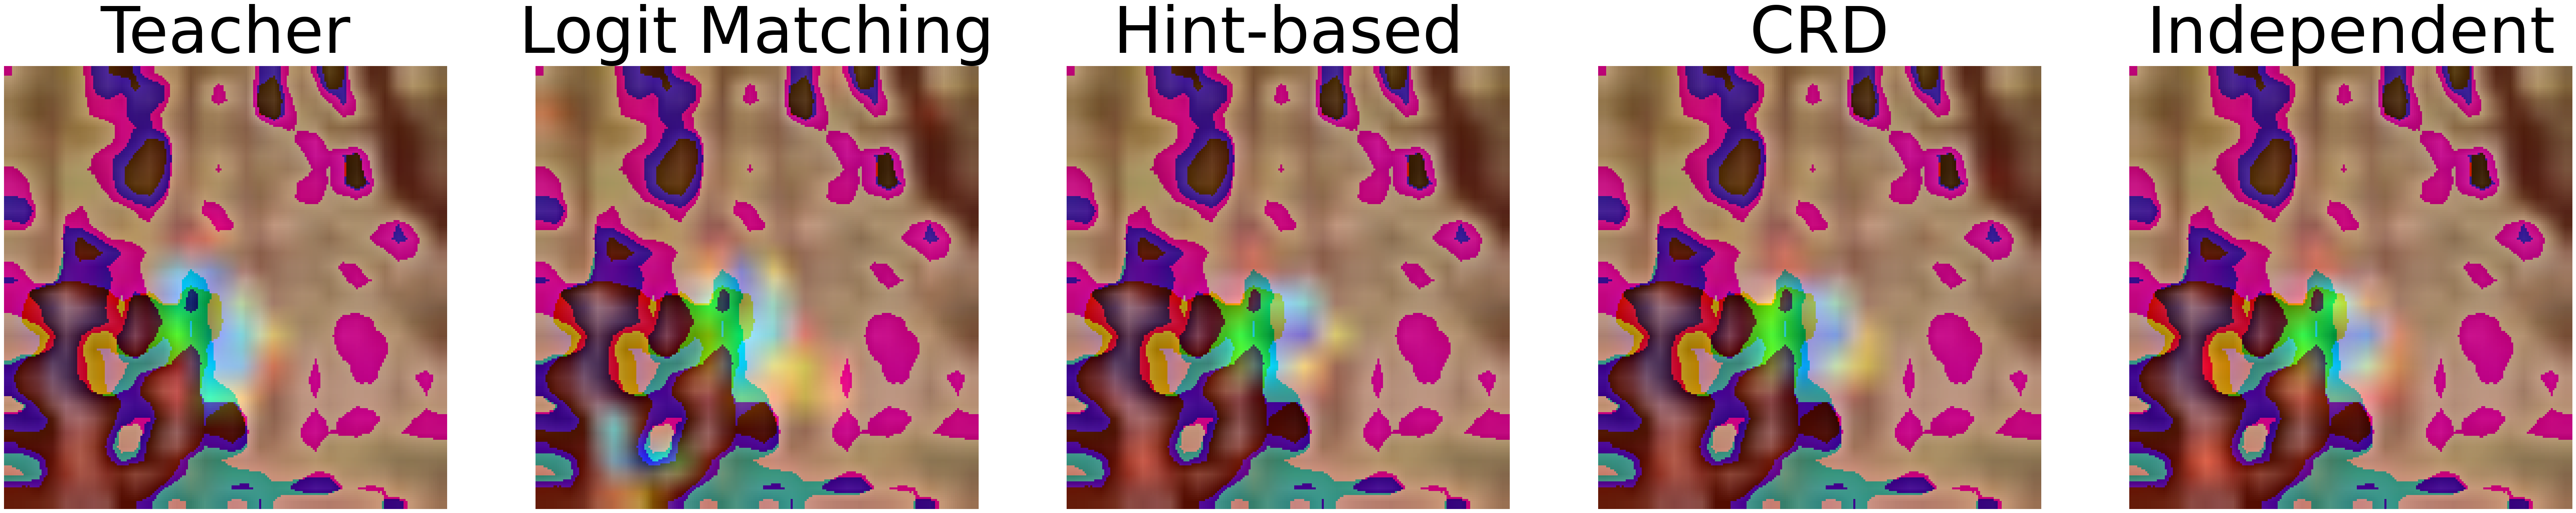

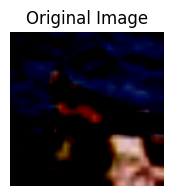

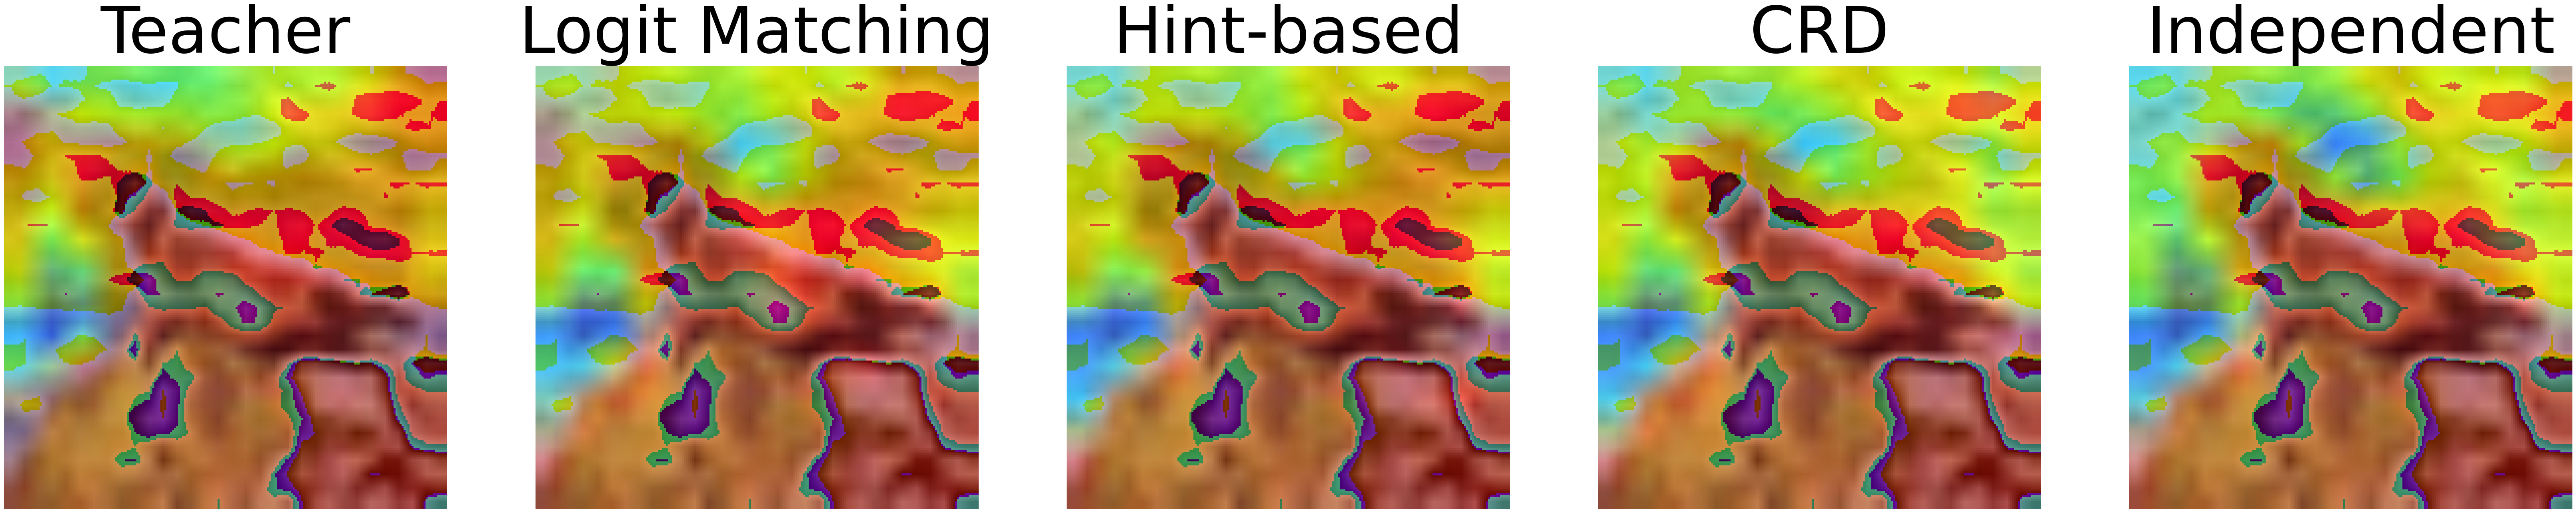

IoU between Image 0 Teacher and Logit Matching: 0.3103
IoU between Image 0 Teacher and Hint-based: 0.5000
IoU between Image 0 Teacher and CRD: 0.3333
IoU between Image 0 Teacher and Independent: 0.2424
IoU between Image 1 Teacher and Logit Matching: 0.5000
IoU between Image 1 Teacher and Hint-based: 0.4000
IoU between Image 1 Teacher and CRD: 0.4444
IoU between Image 1 Teacher and Independent: 0.5556
IoU between Image 2 Teacher and Logit Matching: 0.4091
IoU between Image 2 Teacher and Hint-based: 0.4348
IoU between Image 2 Teacher and CRD: 0.4444
IoU between Image 2 Teacher and Independent: 0.3514


In [30]:
# Load a few query images from the test set
query_images, _ = next(iter(test_loader))
query_images = query_images[:3]  # Select the first 5 images

# Models to evaluate
models = {
    "Teacher": teacher,
    "Logit Matching": student_logit_matching,
    "Hint-based": student_hint,
    "CRD": student_crd,
    "Independent": independent_student
}

# Get Grad-CAM visualizations
gradcam_outputs = get_gradcam_visualizations(models, query_images, class_names)

# Visualize Grad-CAM outputs
for image_key, outputs in gradcam_outputs.items():
    plt.figure(figsize=(4, 2))
    plt.imshow(query_images[int(image_key.split()[1])].detach().cpu().numpy().transpose(1, 2, 0) )
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
    
    visualize_gradcam(query_images[int(image_key.split()[1])], outputs, class_names)

# Calculate IoU between teacher and each student model
iou_results = {}
for image_key, outputs in gradcam_outputs.items():
    teacher_heatmap = outputs["Teacher"]
    
    for model_name, heatmap in outputs.items():
        if model_name != "Teacher":
            iou = calculate_iou(teacher_heatmap, heatmap)
            iou_results[(image_key, model_name)] = iou

# Display IoU results
for (image_key, model_name), iou in iou_results.items():
    print(f"IoU between {image_key} Teacher and {model_name}: {iou:.4f}")

### Task 3.5: Checking for Color Invariance with CRD

In [36]:
import torchvision.transforms as transforms
import random

# Define color jitter augmentation
def random_color_jitter():
    brightness = random.uniform(0, 0.4)
    contrast = random.uniform(0, 0.4)
    saturation = random.uniform(0, 0.4)
    hue = random.uniform(0, 0.2)
    return transforms.ColorJitter(brightness=brightness, contrast=contrast, saturation=saturation, hue=hue)

# Transformation with dynamic color jitter
new_transform = transforms.Compose([
    transforms.Lambda(lambda img: random_color_jitter()(img)),  # Apply random jitter each time
    transforms.Resize((224, 224)),  # Resize for VGG
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False)

BATCH_SIZE = 64
coloured_trainset = datasets.CIFAR100(root='./data2', train=True, download=True, transform=new_transform)
coloured_testset = datasets.CIFAR100(root='./data2', train=False, download=True, transform=new_transform)

coloured_train_loader = DataLoader(coloured_trainset, batch_size=BATCH_SIZE, shuffle=True)
coloured_test_loader  = DataLoader(coloured_testset,  batch_size=BATCH_SIZE, shuffle=False)

# # Load the pre-trained teacher model
teacher_n = models.vgg16(pretrained=True)
teacher_n.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
teacher_n = teacher_n.to(device)
teacher_n.eval()  # Set teacher to evaluation mode


Files already downloaded and verified
Files already downloaded and verified


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher_n.parameters(), lr=1e-4)
train_model(teacher_n, coloured_train_loader, criterion, optimizer, device, epochs=2, dtype="default")

Epoch 1/2: 100%|██████████| 782/782 [13:42<00:00,  1.05s/batch]


Epoch [1/2], Loss: 2.3027, Accuracy: 40.20%


Epoch 2/2: 100%|██████████| 782/782 [13:41<00:00,  1.05s/batch]

Epoch [2/2], Loss: 1.1836, Accuracy: 65.75%


In [39]:
train_model(teacher_n, coloured_train_loader, criterion, optimizer, device, epochs=1, dtype="default")

Epoch 1/1: 100%|██████████| 782/782 [13:41<00:00,  1.05s/batch]

Epoch [1/1], Loss: 0.7874, Accuracy: 76.38%


In [41]:
# Fine-tune the teacher model
# finetune_teacher(teacher, coloured_train_loader, num_epochs=2, learning_rate=0.001)
test_acc = evaluate_model(teacher_n, coloured_test_loader, criterion, device)

print(f"Test Accuracy after fine-tuning the teacher model: {test_acc:.2f}%")

Evaluating: 100%|██████████| 157/157 [01:07<00:00,  2.34batch/s]

Test Loss: 1.0988, Test Accuracy: 69.03%
Test Accuracy after fine-tuning the teacher model: 69.03%


In [37]:
accuracy = evaluate_model(independent_student, coloured_test_loader, criterion, device)
print(f"Validation Accuracy for Contrastive Representation Distillation (CRD): {accuracy:.2f}%\n")

Evaluating: 100%|██████████| 157/157 [00:43<00:00,  3.58batch/s]

Test Loss: 1.2990, Test Accuracy: 63.78%
Validation Accuracy for Contrastive Representation Distillation (CRD): 63.78%



In [42]:
# Training with Contrastive Representation Distillation (CRD)
print("\nTraining student with Contrastive Representation Distillation (CRD)...\n")
student_crd = create_student_model()
optimizer = get_optimizer(student_crd)
for epoch in range(epochs):
    avg_loss, dl = train_student(student_crd, teacher, train_loader, optimizer, T=T, alpha=alpha, loss_type="contrastive")
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    #validating on the coloured test set
    accuracy = evaluate_model(student_crd, coloured_test_loader, criterion, device)
    print(f"Validation Accuracy for Contrastive Representation Distillation (CRD): {accuracy * 100:.2f}%\n")


Training student with Contrastive Representation Distillation (CRD)...



Training: 100%|██████████| 782/782 [20:25<00:00,  1.57s/it]


Epoch [1/2], Loss: 1.9644


Evaluating: 100%|██████████| 157/157 [00:43<00:00,  3.62batch/s]


Test Loss: 1.5170, Test Accuracy: 57.59%
Validation Accuracy for Contrastive Representation Distillation (CRD): 5759.00%



Training: 100%|██████████| 782/782 [20:27<00:00,  1.57s/it]


Epoch [2/2], Loss: 1.4693


Evaluating: 100%|██████████| 157/157 [00:43<00:00,  3.62batch/s]

Test Loss: 1.3544, Test Accuracy: 61.95%
Validation Accuracy for Contrastive Representation Distillation (CRD): 6195.00%



### Task 3.6: Testing the Efficacy of a Larger Teacher

In [10]:
import torchvision.models as models

# Load the pre-trained teacher model
teacher_big = models.vgg19(pretrained=True)
teacher_big.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
teacher_big = teacher_big.to(device)
teacher_big.eval()  # Set teacher to evaluation mode

# Freeze the backbone layers to fine-tune only the classifier
for param in teacher_big.features.parameters():
    param.requires_grad = False

teacher_big = teacher_big.to(device)

# Print summary
print("Model Summary with trainable parameters in the classifier layer only:")
summary(teacher_big, (3, 224, 224))

# Check trainable status for each layer
print("\nTrainable Parameters:")
for name, param in teacher_big.named_parameters():
    print(f"{name}: {'Trainable' if param.requires_grad else 'Frozen'}")

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.

  warnings.warn(msg)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth

100%|██████████| 548M/548M [00:02<00:00, 220MB/s]  


Model Summary with trainable parameters in the classifier layer only:

----------------------------------------------------------------

        Layer (type)               Output Shape         Param #


            Conv2d-1         [-1, 64, 224, 224]           1,792

              ReLU-2         [-1, 64, 224, 224]               0

            Conv2d-3         [-1, 64, 224, 224]          36,928

              ReLU-4         [-1, 64, 224, 224]               0

         MaxPool2d-5         [-1, 64, 112, 112]               0

            Conv2d-6        [-1, 128, 112, 112]          73,856

              ReLU-7        [-1, 128, 112, 112]               0

            Conv2d-8        [-1, 128, 112, 112]         147,584

              ReLU-9        [-1, 128, 112, 112]               0

        MaxPool2d-10          [-1, 128, 56, 56]               0

           Conv2d-11          [-1, 256, 56, 56]         295,168

             ReLU-12          [-1, 256, 56, 56]               0

           Conv2d

In [11]:
# Fine-tune the teacher model
finetune_teacher(teacher_big, train_loader, num_epochs=2, learning_rate=0.001)

Epoch 1/2: 100%|██████████| 782/782 [06:30<00:00,  2.00it/s]


Epoch [1/2], Loss: 2.6861


Epoch 2/2: 100%|██████████| 782/782 [06:31<00:00,  2.00it/s]

Epoch [2/2], Loss: 2.2192


In [13]:
test_acc = evaluate(teacher_big, test_loader)

print(f"Test Accuracy after fine-tuning the teacher model: {test_acc:.2f}%")

Test Accuracy after fine-tuning the teacher model: 52.09%


In [14]:
# Load the untrained student model
student_LM_new = models.vgg11(pretrained=True)  # Set pretrained=False to start with a randomly initialized model
student_LM_new.classifier[6] = nn.Linear(4096, 100)  # Adjust for CIFAR-100 classes
student_LM_new = student_LM_new.to(device)

# Optimizer
optimizer = optim.SGD(student_LM_new.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
#classsifcation loss is defined in train func

# Training the student model with Logit Matching
train_loss_LM_new = []
train_loss_LM_new_distill = []
test_acc_LM_new = []
for epoch in range(1, 3):
    print(f"Epoch {epoch}")
    train_loss,distillation_loss = train_student(student_LM_new, teacher_big, train_loader, optimizer, T=4.0, loss_type="logit_matching")
    test_acc = evaluate(student_LM_new, test_loader)
    print(f"Logit Matching - Epoch {epoch}: Train Loss = {train_loss:.4f}, Distill Loss = {distillation_loss:.4f}, Test Accuracy = {test_acc:.2f}%")
    train_loss_LM_new.append(train_loss)
    train_loss_LM_new_distill.append(distillation_loss)
    test_acc_LM_new.append(test_acc)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.

  warnings.warn(msg)

Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth

100%|██████████| 507M/507M [00:02<00:00, 204MB/s] 


Epoch 1


Training: 100%|██████████| 782/782 [12:07<00:00,  1.07it/s]


Logit Matching - Epoch 1: Train Loss = 3.2600, Distill Loss = 2.2592, Test Accuracy = 57.31%

Epoch 2


Training: 100%|██████████| 782/782 [12:07<00:00,  1.07it/s]


Logit Matching - Epoch 2: Train Loss = 1.9335, Distill Loss = 2.3973, Test Accuracy = 62.08%
